# EXERCISE 10

Clone a corpus from UniversalDependencies. We chose an English UD language for our task.

In [159]:
# # Clone the repository
# !git clone --depth 2 --single-branch --branch dev https://github.com/UniversalDependencies/UD_English-EWT.git

### Read the corpus and import it in a Dataframe

In [2]:
# !pip install conllu
import conllu
import pandas as pd
import numpy as np



def read_conllu_file(file_path):
    """
    Read a conllu file and read each sentences separated
    :param file_path: String
    :return: data in sentences specifically: <class 'conllu.models.SentenceList'>
    """
    # Read the CoNLL-U file
    with open(file_path, "r", encoding="utf-8") as f:
        # Parse the CoNLL-U formatted data
        data = f.read()
        sentences = conllu.parse(data)
    return sentences


# Function to extract tokens and UPOS tags from
# SentenceList object and create a DataFrame
def create_pos_df(sentences):
    """
    Read the conllu sentences list and import them in a dataframe 
    including the information we need
    :param sentences: conllu.models.SentenceList
    :return: pd.DataFrame object
    """
    id_list = []
    tokens_list = []
    upos_tags_list = []

    for sentence in sentences:
        for token in sentence:  # Extract token and UPOS tag
            id = token['id']
            token_text = token['form']
            upos_tag = token['upos']

            id_list.append(id)
            tokens_list.append(token_text)
            upos_tags_list.append(upos_tag)


    # Create dataframe
    dataframe = pd.DataFrame({'id': id_list, "token": tokens_list, "UPOS": upos_tags_list})
    return dataframe

# Initialize the file paths
for split in ('train', 'dev', 'test'):
    file_path = f'UD_English-EWT/en_ewt-ud-{split}.conllu'
    print(file_path)
    sentences = read_conllu_file(file_path)
    
    # Create DataFrame for the current split
    pos_df = create_pos_df(sentences)
    # Assign DataFrame to variable with specific name
    globals()[f"{split}_pos"] = pos_df

UD_English-EWT/en_ewt-ud-train.conllu
UD_English-EWT/en_ewt-ud-dev.conllu
UD_English-EWT/en_ewt-ud-test.conllu


In [3]:
print(f"train_pos dataframe: \n{train_pos}")
print(f"test_pos dataframe: \n{test_pos}")
print(f"dev_pos dataframe: \n{dev_pos}")

# !rm -rf /content/UD_English-EWT # free up memory

train_pos dataframe: 
        id     token   UPOS
0        1        Al  PROPN
1        2         -  PUNCT
2        3     Zaman  PROPN
3        4         :  PUNCT
4        5  American    ADJ
...     ..       ...    ...
207224  22        on    ADP
207225  23        my   PRON
207226  24       car   NOUN
207227  25         )  PUNCT
207228  26         .  PUNCT

[207229 rows x 3 columns]
test_pos dataframe: 
       id       token   UPOS
0       1        What   PRON
1       2          if  SCONJ
2       3      Google  PROPN
3       4     Morphed   VERB
4       5        Into    ADP
...    ..         ...    ...
25445  16  suggesting   VERB
25446  17   exercises   NOUN
25447  18          to   PART
25448  19         use   VERB
25449  20           .  PUNCT

[25450 rows x 3 columns]
dev_pos dataframe: 
       id          token   UPOS
0       1           From    ADP
1       2            the    DET
2       3             AP  PROPN
3       4          comes   VERB
4       5           this    DET
...    .

### Data Preprocessing

We are going to preprocess our data into the dataframe in order to check for any mistakes or incorrect data types


In [4]:
# Check the labels of our data
train_pos.UPOS.unique()

array(['PROPN', 'PUNCT', 'ADJ', 'NOUN', 'VERB', 'DET', 'ADP', 'AUX',
       'PRON', 'PART', 'SCONJ', 'NUM', 'ADV', 'CCONJ', '_', 'INTJ', 'X',
       'SYM'], dtype=object)

### UPOS column contains the string '_' which is incorrect for our training, development and test set. So, we are going to drop the rows that include this *UPOS*

In [5]:
# Drop rows that contain UPOS = '_'
train_pos = train_pos[train_pos.UPOS != '_']
test_pos = test_pos[test_pos.UPOS != '_']
dev_pos = dev_pos[dev_pos.UPOS != '_']

In [6]:
# Check the id for each word
train_pos[train_pos.id.apply(lambda x: not isinstance(x, int))]

,id,token,UPOS
1555,"(8, ., 1)",reported,VERB
6878,"(22, ., 1)",used,VERB
7455,"(22, ., 1)",used,VERB
26698,"(11, ., 1)",called,VERB
41368,"(14, ., 1)",is,VERB
49621,"(16, ., 1)",keep,VERB
68116,"(20, ., 1)",reflect,VERB
78217,"(12, ., 1)",_,AUX
86111,"(21, ., 1)",recruited,VERB
86987,"(9, ., 1)",wish,VERB


### So, we have wrong id's. We must drop these values.

In [7]:
print(f'The length of the training set before the preprocess: {len(train_pos)}')

train_pos = train_pos[train_pos.id.apply(lambda x: isinstance(x, int))]
dev_pos = dev_pos[dev_pos.id.apply(lambda x: isinstance(x, int))]
test_pos = test_pos[test_pos.id.apply(lambda x: isinstance(x, int))]

# Reset the index of our dataframes because we dropped some rows
train_pos = train_pos.reset_index()
dev_pos = dev_pos.reset_index()
test_pos = test_pos.reset_index()

print(f'After the preprocess: {len(train_pos)}')

The length of the training set before the preprocess: 204615
After the preprocess: 204578


### Use Word2Vec for creating word embeddings

### Load the pre-trained model (word2vec-google-news-300)

In [8]:
import gensim.downloader as api
from gensim.models import Word2Vec

# Download and load the pre-trained Word2Vec model
word2vec_model = api.load("word2vec-google-news-300")

In [9]:
print(f'The length of Google pre-trained model with word embeddings is: {len(word2vec_model)}')

The length of Google pre-trained model with word embeddings is: 3000000


### Window based approach with Word2Vec

In [10]:
from tqdm import tqdm


def make_sentences(dataframe):
    """
    Make sentences from the train, development and test set in order
    to create windows for each word
    :param dataframe: pandas df
    :return: array of sentences
    :return: array of position of each word
    """
    all_sents = []
    all_positions = []
    sentence = []
    position = []
    cnt = 0
    with tqdm(total = len(dataframe)) as pbar:
        for index, row in dataframe.iterrows():
            id = row['id']
            token= row['token']
            if id > cnt:
                cnt = id
                sentence.append(token)
                position.append(index)
            else:
                all_sents.append(sentence)
                all_positions.append(position)
                sentence = []
                sentence.append(token)
                position= []
                position.append(index)
                cnt=id
            pbar.update(1)  # Update the progress bar
        all_sents.append(sentence)
        all_positions.append(position)

    return all_sents, all_positions

all_train_sents, all_train_positions = make_sentences(train_pos)
print(f'The total sentences of the training set is: {len(all_train_sents)}')
all_dev_sents, all_dev_positions = make_sentences(dev_pos)
print(f'The total sentences of the development set is: {len(all_dev_sents)}')
all_test_sents, all_test_positions = make_sentences(test_pos)
print(f'The total sentences of the test set is: {len(all_test_sents)}')

100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 204578/204578 [00:07<00:00, 27534.53it/s]


The total sentences of the training set is: 12544


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 25149/25149 [00:00<00:00, 27293.73it/s]


The total sentences of the development set is: 2001


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 25094/25094 [00:01<00:00, 24539.20it/s]

The total sentences of the test set is: 2077


### Create and assign window of size equal to 5

In [11]:
def make_windows(dataframe, sentences, positions, wd_size):
    """
    Make the sliding window for size of our choice in order
    to train our MLP. Use of special token '<PAD>' for words that
    does not reach the desired size.
    :param dataframe: pandas df 
    :param sentences: array of sentences (2D)
    :param positions: array of position for each word
    :param wd_size: int (size of the window)
    :return: array of windows for each word
    :return: array of UPOS tag for each window
    """
    windows = []
    upos_tag = []
    with tqdm(total = len(sentences)) as pbar:
        for sent, pos in zip(sentences, positions):
            padded_sentence = ['<PAD>'] * (wd_size // 2) + sent + ['<PAD>'] * (wd_size // 2)
            for i in range(len(sent)):
                window = padded_sentence[i:i+wd_size]
                windows.append(window)
                upos_tag.append(dataframe.iloc[pos[i]].UPOS)
            pbar.update(1)  # Update the progress bar

    return windows, upos_tag


train_windows, y_train = make_windows(train_pos, all_train_sents, all_train_positions, wd_size=5)
print(f'The length of the windows of the training set is: {len(train_windows)}')
dev_windows, y_dev = make_windows(dev_pos, all_dev_sents, all_dev_positions, wd_size=5)
print(f'The length of the windows of the development set is: {len(dev_windows)}')
test_windows, y_test = make_windows(test_pos, all_test_sents, all_test_positions, wd_size=5)
print(f'The length of the windows of the training set is: {len(test_windows)}')


100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 12544/12544 [00:08<00:00, 1564.05it/s]


The length of the windows of the training set is: 204578


100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 2001/2001 [00:00<00:00, 2073.72it/s]


The length of the windows of the development set is: 25149


100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 2077/2077 [00:00<00:00, 2138.35it/s]

The length of the windows of the training set is: 25094


### Transform the windows into word embeddings via Word2Vec

In [12]:
# Transform windows of training set into word embeddings
train_windows_emb = []
with tqdm(total=len(train_windows)) as pbar:
    for window in train_windows:
        embeddings = [word2vec_model[word] if word in word2vec_model.key_to_index else np.zeros(word2vec_model.vector_size) for word in window]
        train_windows_emb.append(embeddings)
        pbar.update(1)

train_windows_emb = np.array(train_windows_emb)

print(f'Example of a window embedding in the training set:\n {train_windows_emb[1][3]}')

100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 204578/204578 [00:01<00:00, 127267.18it/s]


Example of a window embedding in the training set:
 [-0.04931641  0.23828125 -0.11669922 -0.22070312 -0.0625      0.26171875
  0.08251953 -0.20214844 -0.08300781  0.10742188 -0.39453125 -0.17089844
 -0.03466797  0.18945312 -0.20800781 -0.08642578 -0.26953125 -0.39453125
  0.30078125  0.19042969 -0.18847656 -0.08398438 -0.02233887  0.14257812
  0.25390625  0.14355469 -0.07177734  0.08935547  0.02514648 -0.265625
 -0.16894531 -0.27929688  0.3046875   0.24023438 -0.01312256 -0.06689453
  0.05224609  0.19628906  0.01190186 -0.203125    0.14257812  0.1484375
 -0.0390625   0.20703125  0.27148438  0.01879883 -0.1953125  -0.3984375
 -0.12255859  0.05126953  0.24609375 -0.16796875  0.26757812  0.11816406
 -0.10986328  0.00245667 -0.15429688  0.11132812 -0.16210938 -0.43945312
  0.04052734  0.05078125 -0.12792969 -0.09326172  0.12695312 -0.04296875
  0.45703125  0.10595703  0.13085938  0.22265625 -0.17089844 -0.02990723
 -0.05175781 -0.11767578 -0.34375    -0.15429688  0.21875     0.0859375
  0.

In [13]:
# Transform windows of development set into word embeddings
dev_windows_emb = []
with tqdm(total=len(dev_windows)) as pbar:
    for window in dev_windows:
        embeddings = [word2vec_model[word] if word in word2vec_model.key_to_index else np.zeros(word2vec_model.vector_size) for word in window]
        dev_windows_emb.append(embeddings)
        pbar.update(1)

dev_windows_emb = np.array(dev_windows_emb)

print(f'Example of a window embedding in the development set:\n {dev_windows_emb[1][3]}')

100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 25149/25149 [00:00<00:00, 133052.83it/s]


Example of a window embedding in the development set:
 [ 0.04345703  0.10693359  0.03979492  0.05004883 -0.07421875 -0.2265625
  0.18652344 -0.24316406 -0.16113281 -0.12402344 -0.19824219 -0.12988281
  0.08740234  0.06445312 -0.13476562 -0.11376953  0.21582031  0.0625
 -0.19824219 -0.02270508 -0.296875    0.2578125   0.27929688 -0.1328125
  0.07568359 -0.25390625 -0.23828125 -0.01416016  0.25        0.40039062
  0.24511719  0.09863281 -0.07373047 -0.25976562  0.06445312  0.10253906
 -0.08837891 -0.03393555 -0.41601562  0.45898438 -0.234375   -0.06640625
  0.08740234  0.06689453  0.17773438 -0.02001953 -0.12792969  0.23339844
 -0.18359375  0.265625   -0.2734375   0.36132812  0.09228516 -0.06079102
 -0.09082031  0.2109375  -0.1875     -0.08203125 -0.22070312 -0.16015625
  0.03271484  0.11279297 -0.25390625  0.16992188  0.3359375   0.39453125
  0.20019531 -0.00921631  0.07519531  0.24511719 -0.12304688  0.11572266
 -0.25976562 -0.09277344 -0.36914062  0.48046875  0.06030273 -0.14746094
  

In [14]:
# Transform windows of test set into word embeddings
test_windows_emb = []
with tqdm(total=len(test_windows)) as pbar:
    for window in test_windows:
        embeddings = [word2vec_model[word] if word in word2vec_model.key_to_index else np.zeros(word2vec_model.vector_size) for word in window]
        test_windows_emb.append(embeddings)
        pbar.update(1)

test_windows_emb = np.array(test_windows_emb)
print(f'Example of a window embedding in the test set:\n {test_windows_emb[1][3]}')

# del word2vec_model # delete model to save up memory


100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 25094/25094 [00:00<00:00, 129284.10it/s]


Example of a window embedding in the test set:
 [ 0.125      -0.12402344 -0.13769531  0.13085938 -0.39453125 -0.07666016
  0.15234375  0.12792969  0.16894531 -0.13964844 -0.02636719  0.09375
  0.12890625 -0.10009766 -0.171875    0.07421875  0.35742188 -0.09228516
 -0.03076172 -0.07958984 -0.10693359  0.07910156 -0.05615234  0.06884766
 -0.22070312 -0.15820312  0.16503906  0.06445312  0.17285156  0.13867188
 -0.265625    0.06542969 -0.17382812 -0.16210938 -0.0067749  -0.0625
  0.04833984  0.14453125  0.27929688  0.49023438  0.11083984  0.05810547
  0.10742188  0.20996094 -0.06982422  0.08398438 -0.28515625 -0.00335693
 -0.09375    -0.12792969  0.04443359  0.05151367 -0.29296875 -0.07470703
 -0.11572266  0.23925781 -0.25195312  0.0168457  -0.09667969 -0.09228516
 -0.02722168 -0.13867188 -0.00830078  0.19628906 -0.5859375  -0.15332031
 -0.26367188  0.01672363 -0.22558594  0.15527344 -0.45703125  0.20019531
 -0.06494141 -0.00872803 -0.0625      0.02246094  0.20507812 -0.21386719
 -0.071777

## Baseline Models

### Logistic Regression baseline

In [15]:
print(train_windows_emb.shape)

(204578, 5, 300)


### Classification report (Precision, recall, F1)
* Also, Macro-averaged precision, recall, F1

In [16]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, precision_recall_curve, auc

train_windows_emb_concat = train_windows_emb.reshape(train_windows_emb.shape[0], -1)
dev_windows_emb_concat = dev_windows_emb.reshape(dev_windows_emb.shape[0], -1)
test_windows_emb_concat = test_windows_emb.reshape(test_windows_emb.shape[0], -1)

clf = LogisticRegression()
clf.fit(train_windows_emb_concat, y_train)

C:\1. Python\MLP_Classifier\venv\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression()

In [17]:
def classification_reports(predictions_train, predictions_dev, predictions_test, y_train, y_dev, y_test, class_names):
    """
    Create a function for the classification report for the baseline model for all labels
    :param predictions_train: np.array
    :param predictions_dev: np.array
    :param predictions_test: np.array
    :param y_train: np.array
    :param y_dev: np.array
    :param y_test: np.array
    :param class_names: array of strings
    :return: null
    """
    classification_report_train = classification_report(y_train, predictions_train, target_names=class_names)

    classification_report_dev = classification_report(y_dev, predictions_dev, target_names=class_names)

    classification_report_test = classification_report(y_test, predictions_test, target_names=class_names)

    combined_cl_report = f'\n\t\tClassification report on Training Set: \n\n{classification_report_train}'
    combined_cl_report += f'\n\t\tClassification report on Development Set: \n\n{classification_report_dev}'
    combined_cl_report += f'\n\t\tClassification report on Testing Set: \n\n{classification_report_test}'

    print(combined_cl_report)

In [18]:
class_labels = train_pos.UPOS.unique()
# Train set prediction
predictions_train = clf.predict(train_windows_emb_concat)
    
# Validation/Development set prediction
predictions_dev = clf.predict(dev_windows_emb_concat)

# Test set prediction
predictions_test = clf.predict(test_windows_emb_concat)


classification_reports(predictions_train, predictions_dev, predictions_test, y_train, y_dev, y_test, class_names=class_labels)


		Classification report on Training Set: 

              precision    recall  f1-score   support

       PROPN       0.91      0.90      0.90     13153
       PUNCT       0.88      0.89      0.88     17788
         ADJ       0.91      0.90      0.91     10113
        NOUN       0.98      0.98      0.98     12814
        VERB       0.71      0.56      0.63      6688
         DET       0.95      0.96      0.95     16300
         ADP       0.97      0.90      0.94       693
         AUX       0.94      0.93      0.93     34804
        PRON       0.88      0.81      0.84      4126
        PART       0.89      0.90      0.89      5748
       SCONJ       0.99      0.99      0.99     18661
         NUM       0.92      0.89      0.90     12620
         ADV       0.78      0.90      0.84     23597
       CCONJ       0.92      0.85      0.89      3820
        INTJ       0.95      0.71      0.81       721
           X       0.95      0.94      0.95     22577
         SYM       0.91      0.48    

### Precision-Recall AUC score for each class along with macro-averaged precision-recall AUC score

### Transform the target variables from strings to integers
* Here the idea is that each value inside y_train, y_dev, y_test should be transformed to an integer based on the position the respective value holds on the class_labels array-like object.

In [19]:

# Find the unique classes
class_labels = train_pos.UPOS.unique()

# Mapping class names to their indices in target_names
class_indices = {class_name: i for i, class_name in enumerate(class_labels)}

# Convert class names to indices
y_train = np.array([class_indices[class_name] for class_name in y_train])
y_dev = np.array([class_indices[class_name] for class_name in y_dev])
y_test = np.array([class_indices[class_name] for class_name in y_test])

### Calculate Precision-Recall AUC scores and their macro-average.


In [21]:
def precision_recall_auc_scores(train_embeddings, dev_embeddings,test_embeddings, y_train, y_dev, y_test, model):
    """
    Calculate precision-recall AUC for each class
    :param train_embeddings: np.array
    :param dev_embeddings: np.array
    :param test_embeddings: np.array
    :param y_train: np.array
    :param y_dev: np.array
    :param y_test: np.array
    :param model: logisticregression or kera.src engine
    :return: Null
    """
    precision_train = dict()
    recall_train = dict()
    pr_auc_train = dict()
    precision_dev = dict()
    recall_dev = dict()
    pr_auc_dev = dict()
    precision_test = dict()
    recall_test = dict()
    pr_auc_test = dict()



    for i, label in enumerate(class_labels):
        precision_train[label], recall_train[label], _ = precision_recall_curve(y_train == i, model.predict_proba(train_windows_emb_concat)[:, i])
        pr_auc_train[label] = auc(recall_train[label], precision_train[label])
        print(f'Precision-Recall AUC for {label} on Training Set: {pr_auc_train[label]}')

        precision_dev[label], recall_dev[label], _ = precision_recall_curve(y_dev == i, model.predict_proba(dev_windows_emb_concat)[:, i])
        pr_auc_dev[label] = auc(recall_dev[label], precision_dev[label])
        print(f'Precision-Recall AUC for {label} on Development Set: {pr_auc_dev[label]}')

        precision_test[label], recall_test[label], _ = precision_recall_curve(y_test == i, model.predict_proba(test_windows_emb_concat)[:, i])
        pr_auc_test[label] = auc(recall_test[label], precision_test[label])
        print(f'Precision-Recall AUC for {label} on Test Set: {pr_auc_test[label]}')


    # Calculate macro-averaged precision-recall AUC scores
    macro_avg_pr_auc_train = np.mean(list(pr_auc_train.values()))
    macro_avg_pr_auc_dev = np.mean(list(pr_auc_dev.values()))
    macro_avg_pr_auc_test = np.mean(list(pr_auc_test.values()))

    print(f'\n\nMacro-averaged Precision-Recall AUC on Training Set: {macro_avg_pr_auc_train}')
    print(f'Macro-averaged Precision-Recall AUC on Development Set: {macro_avg_pr_auc_dev}')
    print(f'Macro-averaged Precision-Recall AUC on Test Set: {macro_avg_pr_auc_test}')

    return

In [22]:
precision_recall_auc_scores(train_windows_emb_concat, dev_windows_emb_concat, test_windows_emb_concat, y_train, y_dev, y_test, model=clf)

Precision-Recall AUC for PROPN on Training Set: 0.06729852768121708
Precision-Recall AUC for PROPN on Development Set: 0.07791696943804177
Precision-Recall AUC for PROPN on Test Set: 0.08829733298179378
Precision-Recall AUC for PUNCT on Training Set: 0.24818629498574885
Precision-Recall AUC for PUNCT on Development Set: 0.2612550145318556
Precision-Recall AUC for PUNCT on Test Set: 0.2585054097587265
Precision-Recall AUC for ADJ on Training Set: 0.08246753130999487
Precision-Recall AUC for ADJ on Development Set: 0.09991734674187358
Precision-Recall AUC for ADJ on Test Set: 0.09621791829394194
Precision-Recall AUC for NOUN on Training Set: 0.10795647326057929
Precision-Recall AUC for NOUN on Development Set: 0.10672982460465008
Precision-Recall AUC for NOUN on Test Set: 0.10504365223990161
Precision-Recall AUC for VERB on Training Set: 0.0760110715274379
Precision-Recall AUC for VERB on Development Set: 0.07475262200852531
Precision-Recall AUC for VERB on Test Set: 0.07129031886058608


In [23]:
# Print the shape of our windows embeddings
print(train_windows_emb_concat.shape)
print(train_windows_emb.shape)

(204578, 1500)
(204578, 5, 300)


## Convert labels to 1-hot vectors

In [24]:
from sklearn.preprocessing import LabelBinarizer

lb = LabelBinarizer()
target_names = train_pos.UPOS.unique()
print(f"Target Class Names --> {target_names}")


print(y_train[:50])
print(class_indices)

y_train_1_hot = lb.fit_transform(y_train)
y_dev_1_hot = lb.transform(y_dev)
y_test_1_hot = lb.transform(y_test)


print('There should be an 1 at position 6 here : y_dev_1_hot[0]: {}'.format(y_dev_1_hot[0]))
print(f'The value here should be corresponding to the position,namely, it should be 6 : y_dev[0]: {y_dev[0]}')

Target Class Names --> ['PROPN' 'PUNCT' 'ADJ' 'NOUN' 'VERB' 'DET' 'ADP' 'AUX' 'PRON' 'PART'
 'SCONJ' 'NUM' 'ADV' 'CCONJ' 'INTJ' 'X' 'SYM']
[0 1 0 1 2 3 4 0 0 0 1 0 1 5 3 6 5 3 6 5 3 6 0 1 6 5 2 3 1 1 5 3 6 5 2 3 7
 7 4 8 3 6 3 9 4 1 1 0 1 2]
{'PROPN': 0, 'PUNCT': 1, 'ADJ': 2, 'NOUN': 3, 'VERB': 4, 'DET': 5, 'ADP': 6, 'AUX': 7, 'PRON': 8, 'PART': 9, 'SCONJ': 10, 'NUM': 11, 'ADV': 12, 'CCONJ': 13, 'INTJ': 14, 'X': 15, 'SYM': 16}
There should be an 1 at position 6 here : y_dev_1_hot[0]: [0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0]
The value here should be corresponding to the position,namely, it should be 6 : y_dev[0]: 6


In [25]:
print(y_dev_1_hot)

[[0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [1 0 0 ... 0 0 0]
 ...
 [0 0 0 ... 0 0 0]
 [0 0 1 ... 0 0 0]
 [0 0 0 ... 0 0 0]]


## Multi-Layer Perceptron Keras implementation

* The initialization here is a starting point in comparison to our baseline logistic regression clf.

In [26]:
# Import libraries
import keras
from keras.layers import InputLayer
from keras.layers import Activation, Dropout, Dense, Input,BatchNormalization, Flatten, Embedding
from keras.models import Model, Sequential
from keras.optimizers import Adam
from keras.preprocessing.text import Tokenizer
from keras.preprocessing.sequence import pad_sequences
from keras.callbacks import ModelCheckpoint, EarlyStopping, Callback
from sklearn.preprocessing import LabelBinarizer
from sklearn.model_selection import train_test_split


def create_MLP_model(input_dimensions, act_func):
    """
    Create a deep feed forward network with Dense layers
    Add techniques such as dropout and Batch Normalization
    :param max_words: String (method of learning the parameters)
    :return: class keras.src.engine
    """
    model = Sequential()

    # First Layer
    model.add(Dense(1024, input_dim=input_dimensions, activation=act_func[0]))
    model.add(BatchNormalization())
    model.add(Dropout(0.3))
    # Second Layer
    model.add(Dense(512, activation=act_func[1]))
    model.add(BatchNormalization())
    model.add(Dropout(0.3))

    # Third Layer
    model.add(Dense(1024, activation=act_func[2]))
    model.add(BatchNormalization())
    model.add(Dropout(0.3))
    # Output Layer
    model.add(Dense(len(target_names), activation=act_func[3])) # Multi classification result needed!

    return model


## Evaluation Preparation

### Custom Keras callback for calculating F1, precision, recall at the end of each epoch

In [27]:
import numpy as np
import os
import tensorflow as tf
from sklearn.metrics import f1_score, recall_score, precision_score


class Metrics(tf.keras.callbacks.Callback):
    def __init__(self, valid_data):
        super(Metrics, self).__init__()
        self.validation_data = valid_data

    def on_epoch_end(self, epoch, logs=None):
        logs = logs or {}
        val_predict = np.argmax(self.model.predict(self.validation_data[0]), -1)
        val_targ = self.validation_data[1]

        if len(val_targ.shape) == 2 and val_targ.shape[1] != 1:
            val_targ = np.argmax(val_targ, -1)
        val_targ = tf.cast(val_targ,dtype=tf.float32)

        _val_f1 = f1_score(val_targ, val_predict, average="weighted",
                           zero_division=1)
        _val_recall = recall_score(val_targ, val_predict, average="weighted",
                                   zero_division=1)
        _val_precision = precision_score(val_targ, val_predict, average="weighted",
                                         zero_division=1)

        logs['val_f1'] = _val_f1
        logs['val_recall'] = _val_recall
        logs['val_precision'] = _val_precision
        print(" — val_f1: %f — val_precision: %f — val_recall: %f" % (_val_f1, _val_precision, _val_recall))
        return

## Word2vec based MLP build (training) and recurrent validation

In [29]:
from sklearn.metrics import f1_score, recall_score, precision_score

adam = Adam(learning_rate = 0.0003)

model = create_MLP_model(input_dimensions=train_windows_emb_concat.shape[1], act_func=['tanh', 'tanh', 'tanh', 'softmax'])
model.compile(
    loss='categorical_crossentropy',
    optimizer=adam,
    metrics=["accuracy"]
    )

# Build the model and print the structure of our model before training
model.build(train_windows_emb_concat.shape[1])  # We need to build our model in order to print the structure
print(model.summary())

# Add an early stopping callback to stop the epochs when we catch the best validation loss
early_stopping_callback = EarlyStopping(
    monitor='val_loss',  # Monitor validation loss for early stopping
    patience=10,           # Number of epochs with no improvement after which training will be stopped
    restore_best_weights=True  # Restore best model weights when early stopping is triggered
)

# Callback to save the Keras model or model weights at some frequency.
MLP_checkpoint = ModelCheckpoint(
    'checkpoints/weights10.hdf5',
    monitor='val_loss',
    mode='min',
    verbose=2,
    save_best_only=True,
    save_weights_only=True
    )

# Start our training
history = model.fit(
    train_windows_emb_concat,
    y_train_1_hot,
    validation_data=(dev_windows_emb_concat, y_dev_1_hot),
    batch_size=128,
    epochs=120,
    shuffle=True,
    callbacks=[Metrics(valid_data=(dev_windows_emb_concat, y_dev_1_hot)),
               early_stopping_callback,
               MLP_checkpoint]
)

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_4 (Dense)             (None, 1024)              1537024   
                                                                 
 batch_normalization_3 (Bat  (None, 1024)              4096      
 chNormalization)                                                
                                                                 
 dropout_3 (Dropout)         (None, 1024)              0         
                                                                 
 dense_5 (Dense)             (None, 512)               524800    
                                                                 
 batch_normalization_4 (Bat  (None, 512)               2048      
 chNormalization)                                                
                                                                 
 dropout_4 (Dropout)         (None, 512)              

### Visualize model's Training History

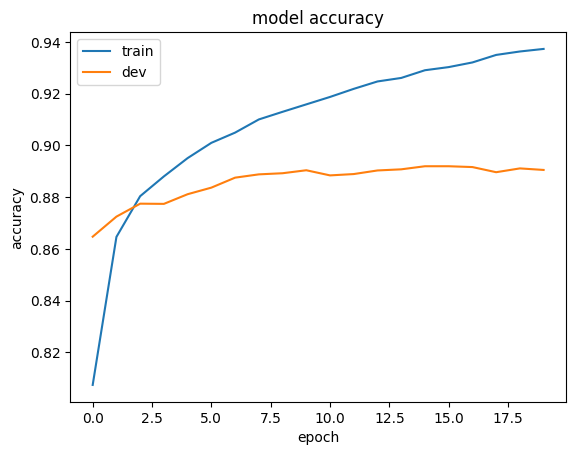

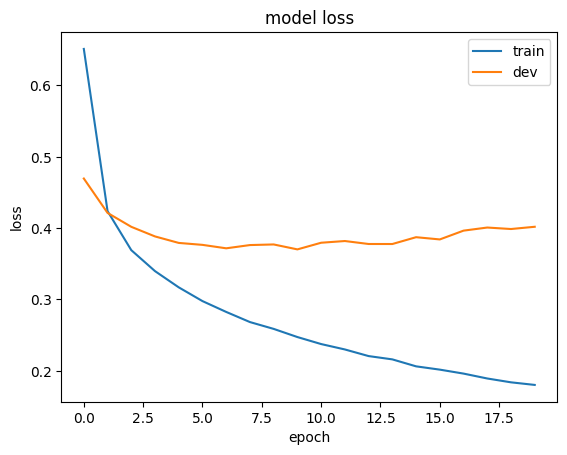

In [30]:
%matplotlib inline
import matplotlib.pyplot as plt

# summarize history for accuracy
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'dev'], loc='upper left')
plt.show()
# summarize history for loss
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'dev'], loc='upper right')
plt.show()

## Performance evaluation of our randomly initialized MLP model
* Randomly initialized: first MLP used without any hyperparameter-tuning

In [31]:
# In order to load the model from the weights file, we need the architecture

model = create_MLP_model(input_dimensions=train_windows_emb_concat.shape[1], act_func=['tanh', 'tanh', 'tanh', 'softmax'])

# Load the weights from the weight's file
model.load_weights("checkpoints/weights10.hdf5")


# Predict training, developement, testing sets
predictions_train = np.argmax(model.predict(train_windows_emb_concat), -1)
predictions_dev = np.argmax(model.predict(dev_windows_emb_concat), -1)
predictions_test = np.argmax(model.predict(test_windows_emb_concat), -1)

# Provide classifcation reports
classification_reports(predictions_train, predictions_dev, predictions_test, y_train, y_dev, y_test, class_names=class_labels)


785/785 [==============================] - 3s 3ms/step

		Classification report on Training Set: 

              precision    recall  f1-score   support

       PROPN       0.97      0.93      0.95     12620
       PUNCT       0.86      0.92      0.89     23597
         ADJ       0.96      0.96      0.96     13153
        NOUN       0.97      0.97      0.97     34804
        VERB       0.99      0.97      0.98     22577
         DET       0.96      0.99      0.97     16300
         ADP       0.91      0.95      0.93     17788
         AUX       0.99      0.99      0.99     12814
        PRON       1.00      1.00      1.00     18661
        PART       0.89      0.97      0.93      5748
       SCONJ       0.96      0.92      0.94      3820
         NUM       0.90      0.88      0.89      4126
         ADV       0.96      0.96      0.96     10113
       CCONJ       0.88      0.62      0.73      6688
        INTJ       0.98      0.94      0.96       693
           X       0.88      0.72   

### Results

Observing the results we get a rough understanding that the our first MLP implementation was successful in terms of surpassing the Logistic Regression baseline we evaluated previously. The above classification reports indicate that the MLP model was better with 95 over 91 on the training set, 89 over 87 on the evaluation data and testing data on the overall accuracy. It should be noted that Logistic Regression performs effectively on classification tasks and many times surpasses NNs implementations. 

We are going to try optimizing our MLP classifier by fine-tuning the hyperparameters.

### Evaluation by precision-recall AUC scores and their macro-average

Create a function that calculates Precision-Recall AUC score and their Macro-average.

In [40]:
from sklearn.metrics import precision_recall_curve, auc
import numpy as np

def precision_recall_auc_scores_mlp(train_embeddings, dev_embeddings, test_embeddings, y_train, y_dev, y_test, model):
    """
    Calculate precision-recall AUC for each class
    :param train_embeddings: np.array
    :param dev_embeddings: np.array
    :param test_embeddings: np.array
    :param y_train: np.array
    :param y_dev: np.array
    :param y_test: np.array
    :param model: logisticregression or kera.src engine
    :return: Null
    """
    precision_train = dict()
    recall_train = dict()
    pr_auc_train = dict()
    precision_dev = dict()
    recall_dev = dict()
    pr_auc_dev = dict()
    precision_test = dict()
    recall_test = dict()
    pr_auc_test = dict()

    # Predict probabilities for train, dev, and test sets
    train_probs = model.predict(train_embeddings)
    dev_probs = model.predict(dev_embeddings)
    test_probs = model.predict(test_embeddings)

    # One-vs-Rest (OvR) strategy for multi-class classification
    for class_label in np.unique(y_train):
        # Convert y_train, y_dev, and y_test to binary labels for the current class
        y_train_binary = (y_train == class_label).astype(int)
        y_dev_binary = (y_dev == class_label).astype(int)
        y_test_binary = (y_test == class_label).astype(int)

        # Calculate precision-recall curve and AUC for the current class
        precision_train[class_label], recall_train[class_label], _ = precision_recall_curve(y_train_binary, train_probs[:, class_label])
        pr_auc_train[class_label] = auc(recall_train[class_label], precision_train[class_label])
        print(f'Precision-Recall AUC for {class_label} on Training Set: {pr_auc_train[class_label]}')

        precision_dev[class_label], recall_dev[class_label], _ = precision_recall_curve(y_dev_binary, dev_probs[:, class_label])
        pr_auc_dev[class_label] = auc(recall_dev[class_label], precision_dev[class_label])
        print(f'Precision-Recall AUC for {class_label} on Development Set: {pr_auc_dev[class_label]}')

        precision_test[class_label], recall_test[class_label], _ = precision_recall_curve(y_test_binary, test_probs[:, class_label])
        pr_auc_test[class_label] = auc(recall_test[class_label], precision_test[class_label])
        print(f'Precision-Recall AUC for {class_label} on Test Set: {pr_auc_test[class_label]}')

    # Calculate macro-averaged precision-recall AUC scores
    macro_avg_pr_auc_train = np.mean(list(pr_auc_train.values()))
    macro_avg_pr_auc_dev = np.mean(list(pr_auc_dev.values()))
    macro_avg_pr_auc_test = np.mean(list(pr_auc_test.values()))

    print(f'\n\nMacro-averaged Precision-Recall AUC on Training Set: {macro_avg_pr_auc_train}')
    print(f'Macro-averaged Precision-Recall AUC on Development Set: {macro_avg_pr_auc_dev}')
    print(f'Macro-averaged Precision-Recall AUC on Test Set: {macro_avg_pr_auc_test}')

    return

In [41]:
# Call the function and print the precision-recall AUC scores
precision_recall_auc_scores_mlp(train_windows_emb_concat, dev_windows_emb_concat, test_windows_emb_concat, y_train, y_dev, y_test, model=model)

785/785 [==============================] - 3s 3ms/step
Precision-Recall AUC for 0 on Training Set: 0.9868808466952838
Precision-Recall AUC for 0 on Development Set: 0.9228197995345706
Precision-Recall AUC for 0 on Test Set: 0.917010700440283
Precision-Recall AUC for 1 on Training Set: 0.9591017470494074
Precision-Recall AUC for 1 on Development Set: 0.9149164870200241
Precision-Recall AUC for 1 on Test Set: 0.8965347569982184
Precision-Recall AUC for 2 on Training Set: 0.9909036038172196
Precision-Recall AUC for 2 on Development Set: 0.9605959652069217
Precision-Recall AUC for 2 on Test Set: 0.952545709557044
Precision-Recall AUC for 3 on Training Set: 0.9943592037940778
Precision-Recall AUC for 3 on Development Set: 0.9675174412009344
Precision-Recall AUC for 3 on Test Set: 0.9646744521662333
Precision-Recall AUC for 4 on Training Set: 0.9969031238651249
Precision-Recall AUC for 4 on Development Set: 0.9779464239925585
Precision-Recall AUC for 4 on Test Set: 0.9804730141007408
Precisi

## Hyperparameter tuning using Keras Tuner library

In [190]:
%%capture
!pip install -U keras-tuner # Install requirements

In [194]:
def build_model(hp):
    model = Sequential()

    layer_index = 0
    for i in range(hp.Int(name='num_layers',min_value=1,max_value=5)):
        if layer_index == 0:
            model.add(Dense(hp.Int(name='hidden_units_'+str(i),min_value=128,max_value=512,step=64),
                            activation=hp.Choice(name='activation_layer'+str(i),values=['relu','tanh']),
                            input_dim=train_windows_emb_concat.shape[1]
                           ))
            model.add(Dropout(hp.Choice(name='dropout_layer_'+str(i),values=[0.1,0.2,0.3,0.4,0.5])))
        else:
            model.add(Dense(hp.Int(name='hidden_units_'+str(i),min_value=128,max_value=512,step=64),
                            activation=hp.Choice(name='activation_layer'+str(i),values=['relu','tanh'])))
            model.add(Dropout(hp.Choice(name='dropout_layer_'+str(i),values=[0.1,0.2,0.3,0.4,0.5])))

        layer_index += 1

    # Add last layer that produces the logits
    model.add(Dense(len(target_names),  activation='softmax'))

    # Tune the learning rate for the optimizer
    # Choose an optimal value from 0.01, 0.001, or 0.0001
    hp_learning_rate = hp.Choice('learning_rate', values=[1e-3, 1e-4])
    model.compile(loss='categorical_crossentropy',optimizer=Adam(learning_rate=hp_learning_rate),
                  metrics=[CategoricalAccuracy()])

    return model

## Initialize the parameters for the RandomSearch

In [195]:
!pip install keras_tuner
from keras.metrics import CategoricalAccuracy  # Import CategoricalAccuracy
import keras_tuner as kt
from tensorflow.keras.callbacks import EarlyStopping

tuner = kt.RandomSearch(build_model,
                        objective=kt.Objective('val_categorical_accuracy',
                                               direction='max'),
                        max_trials=20,
                        directory='KT_dir',
                        project_name='KT_tuning')
early_stopping = EarlyStopping(
    monitor='val_loss', patience=10)
tuner.search_space_summary()

Search space summary
Default search space size: 5
num_layers (Int)
{'default': None, 'conditions': [], 'min_value': 1, 'max_value': 5, 'step': 1, 'sampling': 'linear'}
hidden_units_0 (Int)
{'default': None, 'conditions': [], 'min_value': 128, 'max_value': 512, 'step': 64, 'sampling': 'linear'}
activation_layer0 (Choice)
{'default': 'relu', 'conditions': [], 'values': ['relu', 'tanh'], 'ordered': False}
dropout_layer_0 (Choice)
{'default': 0.1, 'conditions': [], 'values': [0.1, 0.2, 0.3, 0.4, 0.5], 'ordered': True}
learning_rate (Choice)
{'default': 0.001, 'conditions': [], 'values': [0.001, 0.0001], 'ordered': True}


## Perform 20 trials in total with early_stopping added

In [196]:
tuner.search(train_windows_emb_concat, y_train_1_hot,
             validation_data=(dev_windows_emb_concat, y_dev_1_hot), epochs=50, batch_size = 128,
             callbacks=[early_stopping])

Trial 20 Complete [00h 04m 38s]
val_categorical_accuracy: 0.8919241428375244

Best val_categorical_accuracy So Far: 0.8938724994659424
Total elapsed time: 01h 11m 10s


## Trials results:

In [197]:
# Trials summary
tuner.results_summary()

Results summary
Results in KT_dir\KT_tuning
Showing 10 best trials
Objective(name="val_categorical_accuracy", direction="max")

Trial 17 summary
Hyperparameters:
num_layers: 5
hidden_units_0: 256
activation_layer0: tanh
dropout_layer_0: 0.4
learning_rate: 0.0001
hidden_units_1: 512
activation_layer1: relu
dropout_layer_1: 0.1
hidden_units_2: 448
activation_layer2: tanh
dropout_layer_2: 0.3
hidden_units_3: 512
activation_layer3: relu
dropout_layer_3: 0.4
hidden_units_4: 448
activation_layer4: tanh
dropout_layer_4: 0.4
Score: 0.8938724994659424

Trial 13 summary
Hyperparameters:
num_layers: 1
hidden_units_0: 256
activation_layer0: relu
dropout_layer_0: 0.5
learning_rate: 0.001
hidden_units_1: 128
activation_layer1: tanh
dropout_layer_1: 0.3
hidden_units_2: 320
activation_layer2: tanh
dropout_layer_2: 0.4
hidden_units_3: 384
activation_layer3: relu
dropout_layer_3: 0.4
Score: 0.8938327431678772

Trial 11 summary
Hyperparameters:
num_layers: 3
hidden_units_0: 384
activation_layer0: relu
dr

## Get the best model of the 20 trials

In [198]:
# Get best hyper-parameters setup
tuner.get_best_hyperparameters()[0].values

{'num_layers': 5,
 'hidden_units_0': 256,
 'activation_layer0': 'tanh',
 'dropout_layer_0': 0.4,
 'learning_rate': 0.0001,
 'hidden_units_1': 512,
 'activation_layer1': 'relu',
 'dropout_layer_1': 0.1,
 'hidden_units_2': 448,
 'activation_layer2': 'tanh',
 'dropout_layer_2': 0.3,
 'hidden_units_3': 512,
 'activation_layer3': 'relu',
 'dropout_layer_3': 0.4,
 'hidden_units_4': 448,
 'activation_layer4': 'tanh',
 'dropout_layer_4': 0.4}

In [199]:
best_model = tuner.get_best_models(num_models=1)[0]
best_model.summary()


Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 256)               384256    
                                                                 
 dropout (Dropout)           (None, 256)               0         
                                                                 
 dense_1 (Dense)             (None, 512)               131584    
                                                                 
 dropout_1 (Dropout)         (None, 512)               0         
                                                                 
 dense_2 (Dense)             (None, 448)               229824    
                                                                 
 dropout_2 (Dropout)         (None, 448)               0         
                                                                 
 dense_3 (Dense)             (None, 512)               

## Tuner's best MLP - Evaluation 

Classification Reports (Train, Developement, Test)

In [200]:

# Predict training, developement, testing sets
predictions_train = np.argmax(best_model.predict(train_windows_emb_concat), -1)
predictions_dev = np.argmax(best_model.predict(dev_windows_emb_concat), -1)
predictions_test = np.argmax(best_model.predict(test_windows_emb_concat), -1)

# Provide classifcation reports
classification_reports(predictions_train, predictions_dev, predictions_test, y_train, y_dev, y_test, class_names=class_labels)


785/785 [==============================] - 1s 2ms/step

		Classification report on Training Set: 

              precision    recall  f1-score   support

       PROPN       0.95      0.94      0.95     12620
       PUNCT       0.87      0.94      0.91     23597
         ADJ       0.95      0.97      0.96     13153
        NOUN       0.98      0.96      0.97     34804
        VERB       0.98      0.97      0.98     22577
         DET       0.97      0.99      0.98     16300
         ADP       0.95      0.96      0.95     17788
         AUX       0.99      0.99      0.99     12814
        PRON       1.00      1.00      1.00     18661
        PART       0.91      0.98      0.94      5748
       SCONJ       0.96      0.93      0.94      3820
         NUM       0.92      0.91      0.91      4126
         ADV       0.97      0.96      0.96     10113
       CCONJ       0.88      0.70      0.78      6688
        INTJ       0.97      0.92      0.95       693
           X       0.91      0.49   

Precision-Recall AUC scores and their Macro-Average

In [201]:
precision_recall_auc_scores_mlp(train_windows_emb_concat, dev_windows_emb_concat, test_windows_emb_concat, y_train, y_dev, y_test, model=model)

785/785 [==============================] - 2s 2ms/step
Precision-Recall AUC for 0 on Training Set: 0.9508839088030344
Precision-Recall AUC for 0 on Development Set: 0.9087892715380315
Precision-Recall AUC for 0 on Test Set: 0.9042070480325595
Precision-Recall AUC for 1 on Training Set: 0.9107994719128306
Precision-Recall AUC for 1 on Development Set: 0.8994442915447528
Precision-Recall AUC for 1 on Test Set: 0.8727156261862472
Precision-Recall AUC for 2 on Training Set: 0.9423877103895387
Precision-Recall AUC for 2 on Development Set: 0.9285790632091702
Precision-Recall AUC for 2 on Test Set: 0.9254674556165033
Precision-Recall AUC for 3 on Training Set: 0.9728083280691655
Precision-Recall AUC for 3 on Development Set: 0.9539415156898635
Precision-Recall AUC for 3 on Test Set: 0.9532873272023743
Precision-Recall AUC for 4 on Training Set: 0.9772608594104322
Precision-Recall AUC for 4 on Development Set: 0.959463785735339
Precision-Recall AUC for 4 on Test Set: 0.968557490431806
Precisi

### Results

We can observe that by finetuning the hyperparameters of our MLP Classifier we do not improve the results (Accuracy, Precision, Recall & f1-score) either in the validation or the test set. However, we can observe that tuning our Classifier, in most of the trials we are going to take the best results, thus it is a very efficient approach for optimizing our classification task. 